In [1]:
pip install nltk spacy gensim scikit-learn datasets matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.5 MB/s eta 0:00:00


In [4]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 60.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [1]:
from datasets import load_dataset

dataset = load_dataset("amazon_polarity")
data = dataset['train'].select(range(5000))

texts = data['content']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

In [3]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

cleaned_texts = [clean_text(t) for t in texts]

In [5]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
from nltk.tokenize import word_tokenize

tokenized_texts = [word_tokenize(t) for t in cleaned_texts]

In [7]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

filtered_texts = [
    [word for word in tokens if word not in stop_words]
    for tokens in tokenized_texts
]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [8]:
import spacy

nlp = spacy.load("en_core_web_sm")

def lemmatize(tokens):
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc]

lemmatized_texts = [lemmatize(tokens) for tokens in filtered_texts]

In [9]:
from collections import Counter

all_words = [word for doc in lemmatized_texts for word in doc]
vocab = Counter(all_words)

print("Vocabulary size:", len(vocab))

Vocabulary size: 20184


In [10]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

texts_joined = [" ".join(doc) for doc in lemmatized_texts]

# Bag of Words
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(texts_joined)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts_joined)

print("BoW shape:", bow_matrix.shape)
print("TF-IDF shape:", tfidf_matrix.shape)

BoW shape: (5000, 20161)
TF-IDF shape: (5000, 20161)


In [11]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(sentences=lemmatized_texts,
                     vector_size=100,
                     window=5,
                     min_count=2,
                     workers=4)

# Example word vector
print(w2v_model.wv['good'])

[-2.2310641e-01  3.2917222e-01  8.1844382e-02  2.5462231e-01
 -1.2881811e-01 -8.0165178e-01  2.8385755e-01  1.1640581e+00
 -2.1655688e-01 -4.2909351e-01 -2.4040742e-01 -1.0071185e+00
 -6.4140692e-02  6.3212508e-01  1.9909127e-01 -3.2954153e-01
  2.5936407e-01 -5.3567046e-01 -6.0046464e-02 -1.1817213e+00
  2.3945116e-01  2.9958150e-01  6.3598686e-01 -5.5828750e-01
 -2.7118856e-01 -6.5648958e-02 -5.5091155e-01 -2.6848754e-01
 -5.2436244e-01 -1.1928784e-01  5.9079105e-01  2.0834284e-01
  7.3520459e-02 -5.8239800e-01 -5.2602500e-01  7.3097152e-01
 -2.5558224e-01 -7.7872431e-01 -1.5545058e-01 -1.0241779e+00
  2.4449793e-01 -6.0067695e-01 -2.6739395e-01 -3.3901370e-01
  4.2817041e-01 -3.3412638e-01 -5.7914686e-01 -1.7722037e-01
  1.5004157e-01  3.6683178e-01  2.5373945e-01 -2.8887072e-01
 -2.0953359e-01 -4.2709842e-01 -3.6285678e-01  1.6310665e-01
  2.7710974e-01 -8.6769275e-02 -6.8201643e-01  2.8185302e-01
  2.5343788e-01  1.4096217e-01 -2.1476601e-01 -1.2275986e-01
 -8.0584711e-01  5.17026

In [12]:
import numpy as np

def sentence_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

sentence_vectors = np.array([
    sentence_embedding(doc, w2v_model)
    for doc in lemmatized_texts
])

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar(query, top_k=5):
    query_clean = clean_text(query)
    query_tokens = word_tokenize(query_clean)
    query_tokens = [w for w in query_tokens if w not in stop_words]
    query_tokens = lemmatize(query_tokens)

    query_vec = sentence_embedding(query_tokens, w2v_model).reshape(1, -1)

    similarities = cosine_similarity(query_vec, sentence_vectors)[0]
    top_indices = similarities.argsort()[-top_k:][::-1]

    return [(texts[int(i)], float(similarities[int(i)])) for i in top_indices]

results = find_similar("This product is amazing")

for text, score in results:
    print(f"Score: {score:.4f}")
    print(text[:100])
    print("-"*50)

Score: 0.9992
this product is awesome. it hide all your secrets. I would recommend this product to all women and m
--------------------------------------------------
Score: 0.9989
Look carefully at the pictures for this product. The initial picture, without the brand name and wit
--------------------------------------------------
Score: 0.9989
This product was not what I expected so I returned it. Too tight, sizing was misleading. I'll stick 
--------------------------------------------------
Score: 0.9988
The product is wonderful for my hair which is very curly and tends to be frizzy. Smooths it and gets
--------------------------------------------------
Score: 0.9987
I was very excited to buy this scanner and was pleased with its size and weight. However, if you hav
--------------------------------------------------


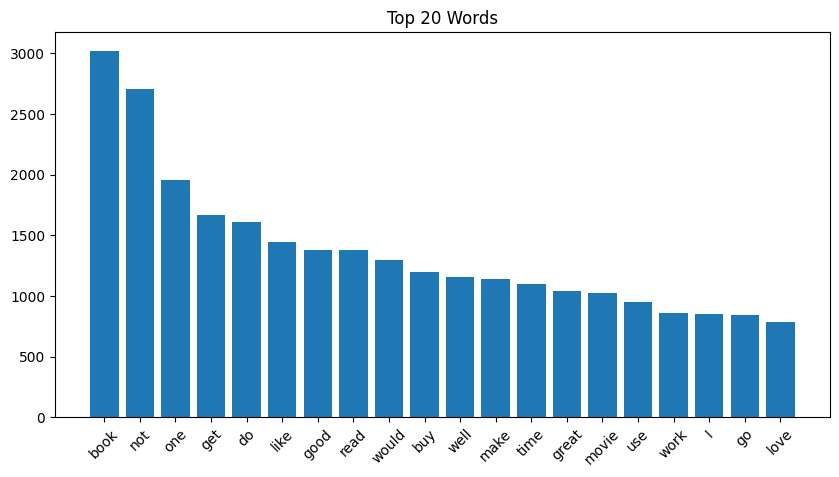

In [16]:
import matplotlib.pyplot as plt

common_words = vocab.most_common(20)
words, counts = zip(*common_words)

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Words")
plt.show()

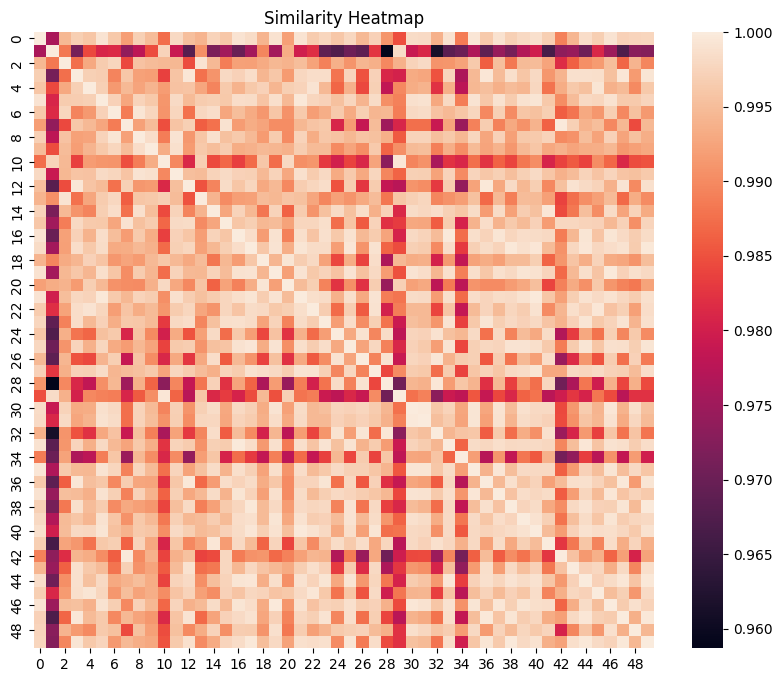

In [18]:
import seaborn as sns

sim_matrix = cosine_similarity(sentence_vectors[:50])

plt.figure(figsize=(10,8))
sns.heatmap(sim_matrix)
plt.title("Similarity Heatmap")
plt.show()